# Economics Real-Data Results / Economics 真实数据结果

This notebook consolidates the formal economics real-data suite: CMDL, plain-LSTM baseline, and the three core ablation variants.
本 notebook 汇总 economics 真实数据正式实验：CMDL、plain-LSTM baseline，以及三个核心 ablation 变体。

## Sections / 结构

- Setup: repo paths, imports, and the single configuration cell.
- Optional direct-run: programmatic training hooks for CMDL, baseline, and ablation.
- Unified comparison: build normalized run-level tables for forecasting and lag/proxy diagnostics.
- Multi-seed summaries and plots: aggregate seeds 0/1/2 and export figures.
- Prediction snapshots: compare canonical runs on a few entities.

## Defaults / 默认行为

- The active plan is `formal_target`.
- Direct-run switches are opt-in and default to `False`.
- The notebook reads from `data/economics/processed/economics_cleaned_long.csv`.
- Outputs are organized under `outputs/notebook_economics/<plan>/...`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"repo_root = {repo_root}")

repo_root = C:\DevSpace\PyDevspace\CMDL


In [14]:
from argparse import Namespace
import importlib

from evaluation import economics_comparison as economics_comparison_module
from experiments import run_economics as run_economics_module
from experiments import run_economics_ablation as run_economics_ablation_module
from experiments import run_economics_lstm_baseline as run_economics_lstm_baseline_module

economics_comparison_module = importlib.reload(economics_comparison_module)
run_economics_module = importlib.reload(run_economics_module)
run_economics_ablation_module = importlib.reload(run_economics_ablation_module)
run_economics_lstm_baseline_module = importlib.reload(run_economics_lstm_baseline_module)

build_economics_comparison = economics_comparison_module.build_economics_comparison
build_task_table = economics_comparison_module.build_task_table
build_interpretability_table = economics_comparison_module.build_interpretability_table
run_cmdl_experiment = run_economics_module.run_experiment
run_baseline_experiment = run_economics_lstm_baseline_module.run_experiment
run_ablation_suite = run_economics_ablation_module.run_suite

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 120, "patience": 20, "log_every": 10},
}

ACTIVE_PLAN = "formal_target"
SEEDS = [0, 1, 2]
CANONICAL_SEED = SEEDS[0]
RUN_CMDL = False
RUN_BASELINE = False
RUN_ABLATIONS = False
DISABLE_MLFLOW = False
TARGET_COLUMN = "ctfp"

DATA_PATH = repo_root / "data" / "economics" / "processed" / "economics_cleaned_long.csv"
OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / ACTIVE_PLAN
CMDL_OUTPUT_DIR = OUTPUT_ROOT / "cmdl"
BASELINE_OUTPUT_DIR = OUTPUT_ROOT / "plain_lstm"
ABLATION_OUTPUT_DIR = OUTPUT_ROOT / "ablation"
COMPARISON_DIR = OUTPUT_ROOT / "comparison"
PLOTS_DIR = OUTPUT_ROOT / "comparison_plots"

for path in [OUTPUT_ROOT, CMDL_OUTPUT_DIR, BASELINE_OUTPUT_DIR, ABLATION_OUTPUT_DIR, COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

COMMON_ARGS = {
    "csv_path": str(DATA_PATH),
    "year_start": 1980,
    "year_end": 2023,
    "train_end_year": 2007,
    "val_end_year": 2013,
    "target_column": TARGET_COLUMN,
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "device": "auto",
    "disable_mlflow": DISABLE_MLFLOW,
}

plan_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
notebook_switches = pd.DataFrame(
    {
        "value": [
            ACTIVE_PLAN,
            DATA_PATH,
            CMDL_OUTPUT_DIR,
            BASELINE_OUTPUT_DIR,
            ABLATION_OUTPUT_DIR,
            COMPARISON_DIR,
            PLOTS_DIR,
            ", ".join(str(seed) for seed in SEEDS),
            CANONICAL_SEED,
            RUN_CMDL,
            RUN_BASELINE,
            RUN_ABLATIONS,
            DISABLE_MLFLOW,
        ]
    },
    index=[
        "ACTIVE_PLAN",
        "DATA_PATH",
        "CMDL_OUTPUT_DIR",
        "BASELINE_OUTPUT_DIR",
        "ABLATION_OUTPUT_DIR",
        "COMPARISON_DIR",
        "PLOTS_DIR",
        "SEEDS",
        "CANONICAL_SEED",
        "RUN_CMDL",
        "RUN_BASELINE",
        "RUN_ABLATIONS",
        "DISABLE_MLFLOW",
    ],
)

display(plan_table)
display(pd.Series({**COMMON_ARGS, **PRESET_CONFIGS[ACTIVE_PLAN]}, name="value").to_frame())
display(notebook_switches)
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,120,20,10


,value
csv_path,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
year_start,1980
year_end,2023
train_end_year,2007
val_end_year,2013
target_column,ctfp
max_missing_share,0.15
lr,0.001
lambda_r,0.1
temperature,1.0


,value
ACTIVE_PLAN,formal_target
DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
CMDL_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
BASELINE_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
ABLATION_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
COMPARISON_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
PLOTS_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
SEEDS,"0, 1, 2"
CANONICAL_SEED,0
RUN_CMDL,False


ACTIVE_PLAN = formal_target
OUTPUT_ROOT = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target


In [3]:
cmdl_summaries: list[dict[str, object]] = []
baseline_summaries: list[dict[str, object]] = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

if RUN_CMDL:
    for seed in SEEDS:
        cmdl_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(CMDL_OUTPUT_DIR),
            experiment_name=f"E4_economics_cmdl_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        cmdl_summary = run_cmdl_experiment(cmdl_args)
        cmdl_summaries.append(cmdl_summary)
        print(
            f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={cmdl_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_CMDL = False; skipping direct CMDL training.")

if RUN_BASELINE:
    for seed in SEEDS:
        baseline_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(BASELINE_OUTPUT_DIR),
            experiment_name=f"E4_economics_lstm_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        baseline_summary = run_baseline_experiment(baseline_args)
        baseline_summaries.append(baseline_summary)
        print(
            f"Baseline seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={baseline_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_BASELINE = False; skipping direct baseline training.")

if RUN_ABLATIONS:
    ablation_args = Namespace(
        **COMMON_ARGS,
        **PRESET_CONFIGS[ACTIVE_PLAN],
        variant="all",
        seeds=SEEDS,
        output_dir=str(ABLATION_OUTPUT_DIR),
        experiment_prefix="E4_economics_ablation",
        smoke=ACTIVE_PLAN == "quick_check",
    )
    ablation_summary_frame, ablation_aggregated_frame = run_ablation_suite(ablation_args)
    display(ablation_summary_frame)
    if not ablation_aggregated_frame.empty:
        display(ablation_aggregated_frame)
else:
    print("RUN_ABLATIONS = False; skipping direct ablation training.")

RUN_CMDL = False; skipping direct CMDL training.
RUN_BASELINE = False; skipping direct baseline training.
RUN_ABLATIONS = False; skipping direct ablation training.


In [15]:
comparison = build_economics_comparison(
    cmdl_root=CMDL_OUTPUT_DIR,
    baseline_root=BASELINE_OUTPUT_DIR,
    ablation_root=ABLATION_OUTPUT_DIR,
)
task_table = build_task_table(comparison)
interpretability_table = build_interpretability_table(comparison)

comparison_path = COMPARISON_DIR / "economics_comparison.csv"
task_table_path = COMPARISON_DIR / "forecast_comparison.csv"
interpretability_path = COMPARISON_DIR / "lag_proxy_diagnostics.csv"

comparison.to_csv(comparison_path, index=False)
task_table.to_csv(task_table_path, index=False)
interpretability_table.to_csv(interpretability_path, index=False)

print(f"comparison rows = {len(comparison)}")
print(f"task table path = {task_table_path}")
print(f"interpretability path = {interpretability_path}")
display(task_table)
display(interpretability_table)

comparison rows = 15
task table path = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison\forecast_comparison.csv
interpretability path = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison\lag_proxy_diagnostics.csv


,display_name,family,variant,seed,experiment,target_column,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,Uniform Lag,ablation,uniform_lag,0,E4_economics_ablation_uniform_lag_seed0,ctfp,1,2.837034,-0.045594,1.571959,4.335729
1,No Recon Regularization,ablation,no_recon_regularization,0,E4_economics_ablation_no_recon_regularization_...,ctfp,5,2.768782,-0.057988,1.567320,4.385006
2,No AC Encoder,ablation,no_ac_encoder,0,E4_economics_ablation_no_ac_encoder_seed0,ctfp,5,2.771364,-0.058632,1.567689,4.387622
3,CMDL,cmdl,None,1,E4_economics_cmdl_seed1,ctfp,1,3.029675,-0.060747,1.580845,4.398145
4,CMDL,cmdl,None,2,E4_economics_cmdl_seed2,ctfp,2,2.893610,-0.069764,1.597144,4.435274
5,Plain LSTM,plain_lstm,None,2,E4_economics_lstm_seed2,ctfp,9,2.859536,-0.074768,1.600236,4.455986
6,Uniform Lag,ablation,uniform_lag,2,E4_economics_ablation_uniform_lag_seed2,ctfp,26,2.984248,-0.080240,1.613011,4.469770
7,Plain LSTM,plain_lstm,None,1,E4_economics_lstm_seed1,ctfp,1,2.853610,-0.087521,1.619266,4.510215
8,No AC Encoder,ablation,no_ac_encoder,2,E4_economics_ablation_no_ac_encoder_seed2,ctfp,23,2.963230,-0.090137,1.620773,4.515943
9,No Recon Regularization,ablation,no_recon_regularization,2,E4_economics_ablation_no_recon_regularization_...,ctfp,8,2.959364,-0.104116,1.625369,4.578959


,display_name,family,variant,seed,experiment,target_column,lag_method,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2
0,No Recon Regularization,ablation,no_recon_regularization,1,E4_economics_ablation_no_recon_regularization_...,ctfp,learned_omega,1.000000,3.926327,0.303777,1.820895,9.365884e-01
1,Plain LSTM,plain_lstm,None,1,E4_economics_lstm_seed1,ctfp,lag_occlusion,0.191716,5.406623,0.982570,2.199584,NaN
2,Plain LSTM,plain_lstm,None,0,E4_economics_lstm_seed0,ctfp,lag_occlusion,0.002569,5.400273,1.248111,2.146421,NaN
3,Uniform Lag,ablation,uniform_lag,1,E4_economics_ablation_uniform_lag_seed1,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,9.376696e-01
4,Uniform Lag,ablation,uniform_lag,0,E4_economics_ablation_uniform_lag_seed0,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,9.176309e-01
5,Uniform Lag,ablation,uniform_lag,2,E4_economics_ablation_uniform_lag_seed2,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,8.197623e-01
6,No AC Encoder,ablation,no_ac_encoder,1,E4_economics_ablation_no_ac_encoder_seed1,ctfp,learned_omega,0.000000,3.745347,0.000000,1.798404,-2.295863e+15
7,No AC Encoder,ablation,no_ac_encoder,2,E4_economics_ablation_no_ac_encoder_seed2,ctfp,learned_omega,0.000000,3.045972,0.000000,1.571578,-3.254807e+15
8,No AC Encoder,ablation,no_ac_encoder,0,E4_economics_ablation_no_ac_encoder_seed0,ctfp,learned_omega,0.000000,6.837674,0.000000,2.018211,-1.728972e+16
9,Plain LSTM,plain_lstm,None,2,E4_economics_lstm_seed2,ctfp,lag_occlusion,-0.009540,5.262721,1.060767,2.175685,NaN


In [9]:
def aggregate_seed_table(frame: pd.DataFrame, metric_columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=["display_name", "family", "variant"])

    available_metrics = [column for column in metric_columns if column in frame.columns]
    if not available_metrics:
        return pd.DataFrame(columns=["display_name", "family", "variant"])

    aggregated = frame.groupby(["display_name", "family", "variant"], dropna=False)[available_metrics].agg(["mean", "std"])
    aggregated.columns = [
        column if isinstance(column, str) else "_".join(part for part in column if part)
        for column in aggregated.columns.to_flat_index()
    ]
    return aggregated.reset_index().sort_values(["family", "display_name"], na_position="last").reset_index(drop=True)


task_seed_summary = aggregate_seed_table(
    comparison,
    ["test_r2", "test_mae", "test_mse", "best_val_task_loss"],
)
interpretability_seed_summary = aggregate_seed_table(
    comparison,
    [
        "test_effective_kstar_proxy_spearman_rho",
        "test_effective_kstar_mean",
        "test_effective_kstar_std",
        "test_effective_lag_entropy_mean",
        "test_proxy_signal_r2",
    ],
)

task_seed_summary.to_csv(COMPARISON_DIR / "forecast_comparison_seed_summary.csv", index=False)
interpretability_seed_summary.to_csv(COMPARISON_DIR / "lag_proxy_diagnostics_seed_summary.csv", index=False)

display(task_seed_summary)
display(interpretability_seed_summary)

,display_name,family,variant,test_r2_mean,test_r2_std,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,best_val_task_loss_mean,best_val_task_loss_std
0,No AC Encoder,ablation,no_ac_encoder,-0.093138,0.036101,1.620252,0.052304,4.530973,0.151426,2.894583,0.106943
1,No Recon Regularization,ablation,no_recon_regularization,-0.097570,0.036749,1.621669,0.052597,4.551064,0.154016,2.893085,0.107728
2,Uniform Lag,ablation,uniform_lag,-0.084656,0.041447,1.618638,0.049732,4.494834,0.173004,2.922682,0.076504
3,CMDL,cmdl,NaN,-0.079111,0.024418,1.603725,0.026783,4.472281,0.098028,2.966617,0.068576
4,Plain LSTM,plain_lstm,NaN,-0.093780,0.022796,1.618734,0.018238,4.534706,0.093405,2.901252,0.077444


,display_name,family,variant,test_effective_kstar_proxy_spearman_rho_mean,test_effective_kstar_proxy_spearman_rho_std,test_effective_kstar_mean_mean,test_effective_kstar_mean_std,test_effective_kstar_std_mean,test_effective_kstar_std_std,test_effective_lag_entropy_mean_mean,test_effective_lag_entropy_mean_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std
0,No AC Encoder,ablation,no_ac_encoder,0.000000,0.000000,4.542998,2.017780,0.000000,0.000000,1.796064,0.223326,-7.613464e+15,8.393591e+15
1,No Recon Regularization,ablation,no_recon_regularization,-0.146740,1.026664,4.627961,1.965043,0.124975,0.157459,1.807218,0.212261,6.770974e-01,4.096231e-01
2,Uniform Lag,ablation,uniform_lag,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,2.302585,0.000000,8.916876e-01,6.308983e-02
3,CMDL,cmdl,NaN,-0.925805,0.037868,5.061881,0.635854,0.109701,0.149276,1.829503,0.078552,8.391274e-01,1.336590e-02
4,Plain LSTM,plain_lstm,NaN,0.061582,0.112862,5.356539,0.081311,1.097150,0.136458,2.173897,0.026627,NaN,NaN


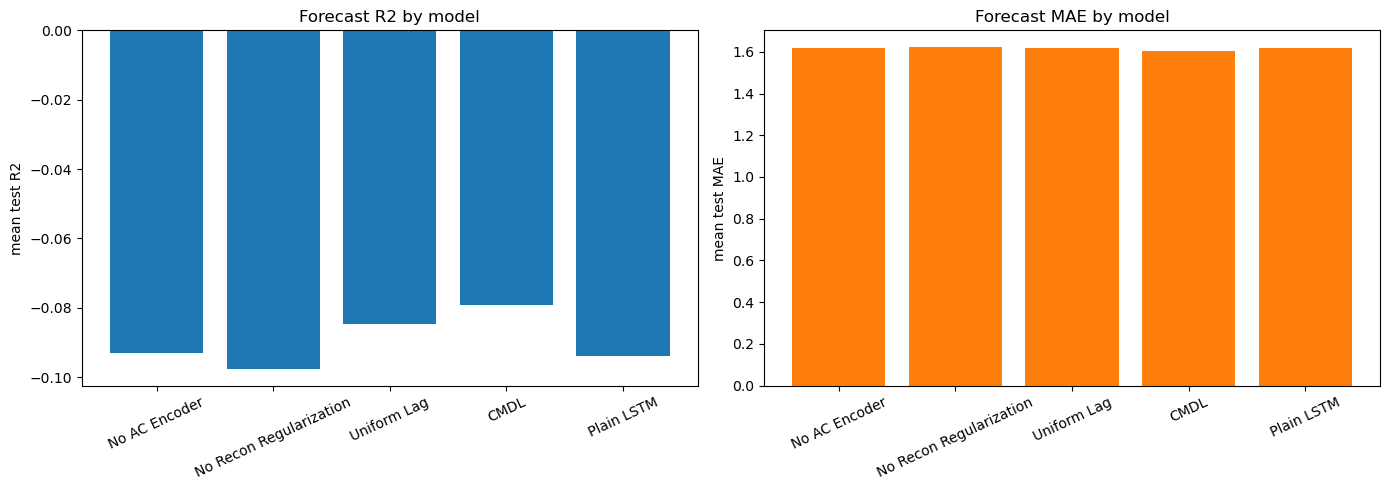

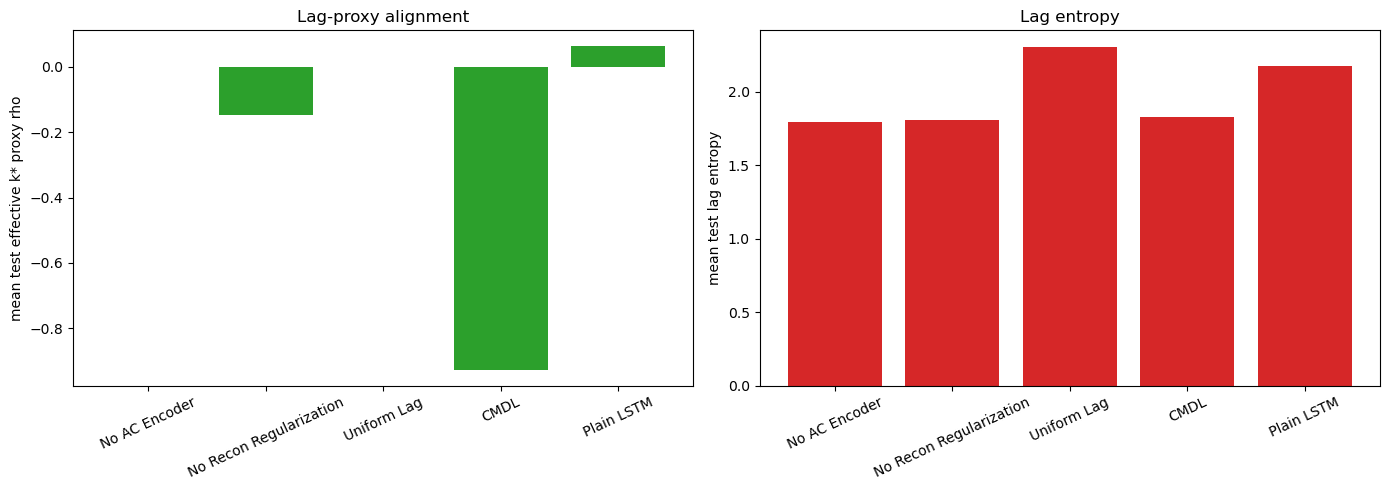

Saved plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\forecast_metrics.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\lag_proxy_diagnostics.png


In [10]:
if task_seed_summary.empty or interpretability_seed_summary.empty:
    print("No comparison results found yet; skipping plots.")
else:
    forecast_plot_frame = task_seed_summary.copy()
    diagnostics_plot_frame = interpretability_seed_summary.copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(forecast_plot_frame["display_name"], forecast_plot_frame["test_r2_mean"], color="#1f77b4")
    axes[0].set_title("Forecast R2 by model")
    axes[0].set_ylabel("mean test R2")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(forecast_plot_frame["display_name"], forecast_plot_frame["test_mae_mean"], color="#ff7f0e")
    axes[1].set_title("Forecast MAE by model")
    axes[1].set_ylabel("mean test MAE")
    axes[1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    forecast_plot_path = PLOTS_DIR / "forecast_metrics.png"
    fig.savefig(forecast_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(
        diagnostics_plot_frame["display_name"],
        diagnostics_plot_frame["test_effective_kstar_proxy_spearman_rho_mean"],
        color="#2ca02c",
    )
    axes[0].set_title("Lag-proxy alignment")
    axes[0].set_ylabel("mean test effective k* proxy rho")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(
        diagnostics_plot_frame["display_name"],
        diagnostics_plot_frame["test_effective_lag_entropy_mean_mean"],
        color="#d62728",
    )
    axes[1].set_title("Lag entropy")
    axes[1].set_ylabel("mean test lag entropy")
    axes[1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    diagnostics_plot_path = PLOTS_DIR / "lag_proxy_diagnostics.png"
    fig.savefig(diagnostics_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    print(f"Saved plots to {forecast_plot_path} and {diagnostics_plot_path}")

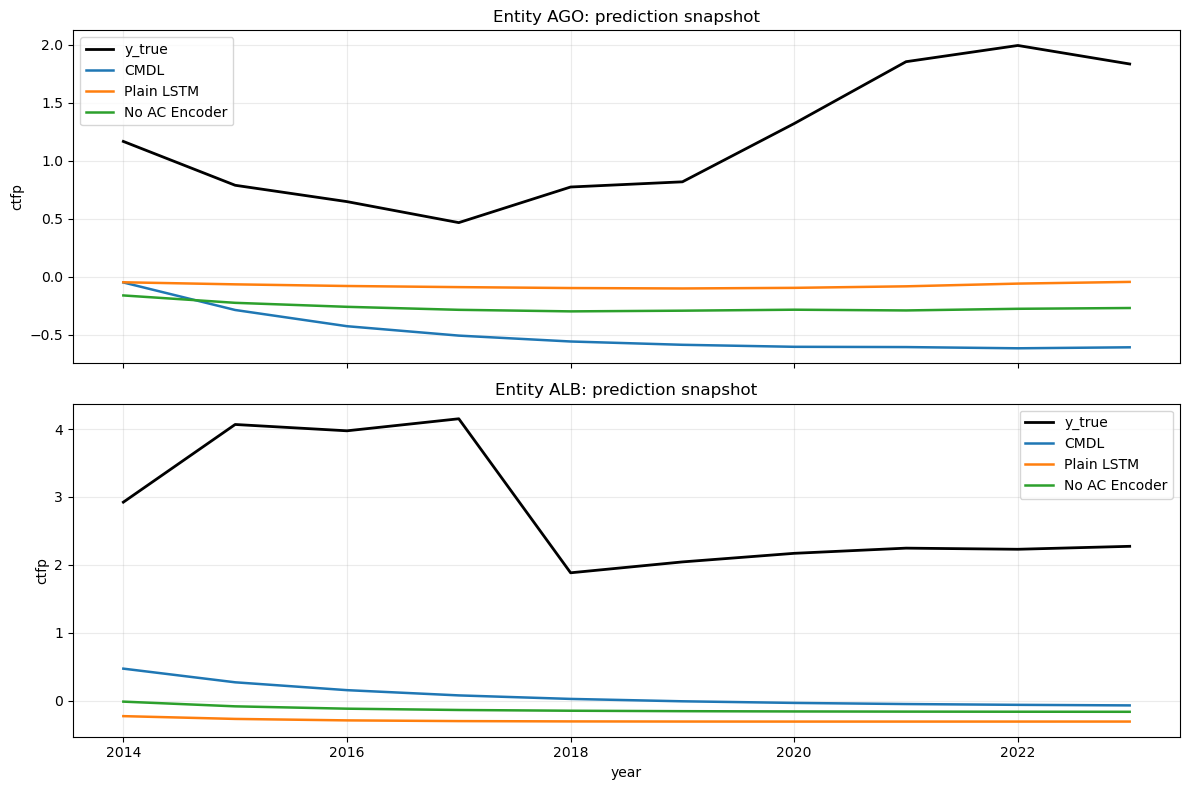

Saved prediction snapshot plot to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\prediction_snapshots.png


In [11]:
prediction_specs = {
    "CMDL": CMDL_OUTPUT_DIR / f"E4_economics_cmdl_seed{CANONICAL_SEED}" / "predictions.csv",
    "Plain LSTM": BASELINE_OUTPUT_DIR / f"E4_economics_lstm_seed{CANONICAL_SEED}" / "predictions.csv",
    "No AC Encoder": ABLATION_OUTPUT_DIR / f"E4_economics_ablation_no_ac_encoder_seed{CANONICAL_SEED}" / "predictions.csv",
}

prediction_frames: dict[str, pd.DataFrame] = {}
for label, path in prediction_specs.items():
    if path.exists():
        prediction_frames[label] = pd.read_csv(path)

if not prediction_frames:
    print("No prediction snapshots found yet; skipping time-series comparison.")
else:
    reference_frame = next(iter(prediction_frames.values()))
    entity_codes = sorted(reference_frame["entity_code"].unique().tolist())[:2]
    fig, axes = plt.subplots(len(entity_codes), 1, figsize=(12, 4 * len(entity_codes)), sharex=True)
    if len(entity_codes) == 1:
        axes = [axes]

    for axis, entity_code in zip(axes, entity_codes):
        baseline_truth = reference_frame[reference_frame["entity_code"] == entity_code]
        axis.plot(baseline_truth["year"], baseline_truth["y_true"], color="black", linewidth=2.0, label="y_true")
        for label, frame in prediction_frames.items():
            entity_frame = frame[frame["entity_code"] == entity_code]
            axis.plot(entity_frame["year"], entity_frame["y_pred"], linewidth=1.8, label=label)
        axis.set_title(f"Entity {entity_code}: prediction snapshot")
        axis.set_ylabel(TARGET_COLUMN)
        axis.grid(alpha=0.25)
        axis.legend()

    axes[-1].set_xlabel("year")
    fig.tight_layout()
    prediction_plot_path = PLOTS_DIR / "prediction_snapshots.png"
    fig.savefig(prediction_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved prediction snapshot plot to {prediction_plot_path}")

## Phase B Screening / Phase B 筛选验证

This section exports a richer Phase B cleaned asset, screens `minimal` and `growth_aware` bundles on both `ctfp` and `rtfpna`, and visualizes forecast plus mechanism diagnostics.
本节导出更丰富的 Phase B 清洗表，对 `minimal` 与 `growth_aware` 两个 bundle 在 `ctfp` 和 `rtfpna` 上做快速筛选，并可视化预测与机制诊断结果。

In [17]:
from argparse import Namespace
import importlib

from data.economics import economics_loader as economics_loader_module
from data.economics import prepare as economics_prepare_module
from evaluation import economics_comparison as economics_comparison_module
from experiments import run_economics as run_economics_module
from experiments import run_economics_lstm_baseline as run_economics_lstm_baseline_module

economics_loader_module = importlib.reload(economics_loader_module)
economics_prepare_module = importlib.reload(economics_prepare_module)
economics_comparison_module = importlib.reload(economics_comparison_module)
run_economics_module = importlib.reload(run_economics_module)
run_economics_lstm_baseline_module = importlib.reload(run_economics_lstm_baseline_module)

save_cleaned_economics_table = economics_prepare_module.save_cleaned_economics_table
DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH = economics_prepare_module.DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH
build_economics_comparison = economics_comparison_module.build_economics_comparison
build_task_table = economics_comparison_module.build_task_table
build_interpretability_table = economics_comparison_module.build_interpretability_table
run_cmdl_experiment = run_economics_module.run_experiment
run_baseline_experiment = run_economics_lstm_baseline_module.run_experiment

PHASE_B_SOURCE_PATH = repo_root / "data" / "economics" / "raw" / "pwt110.csv"
PHASE_B_DATA_PATH = DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH.resolve()
PHASE_B_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / "phase_b_screening"
PHASE_B_CMDL_OUTPUT_DIR = PHASE_B_OUTPUT_ROOT / "cmdl"
PHASE_B_BASELINE_OUTPUT_DIR = PHASE_B_OUTPUT_ROOT / "plain_lstm"
PHASE_B_COMPARISON_DIR = PHASE_B_OUTPUT_ROOT / "comparison"
PHASE_B_PLOTS_DIR = PHASE_B_OUTPUT_ROOT / "comparison_plots"
PHASE_B_FEATURE_BUNDLES = ["minimal", "growth_aware"]
PHASE_B_TARGETS = ["ctfp", "rtfpna"]
PHASE_B_SEED = 0
PHASE_B_PRESET = {"epochs": 4, "patience": 2, "log_every": 1}
PHASE_B_DEVICE = "cpu"
PHASE_B_DISABLE_MLFLOW = True

if not PHASE_B_SOURCE_PATH.exists():
    raise FileNotFoundError(f"Raw PWT source not found at {PHASE_B_SOURCE_PATH}")

for path in [PHASE_B_OUTPUT_ROOT, PHASE_B_CMDL_OUTPUT_DIR, PHASE_B_BASELINE_OUTPUT_DIR, PHASE_B_COMPARISON_DIR, PHASE_B_PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

phase_b_cleaned_path = save_cleaned_economics_table(
    csv_path=PHASE_B_SOURCE_PATH,
    output_path=PHASE_B_DATA_PATH,
    target_column="ctfp",
    year_start=COMMON_ARGS["year_start"],
    year_end=COMMON_ARGS["year_end"],
    max_missing_share=COMMON_ARGS["max_missing_share"],
)

phase_b_settings = pd.DataFrame(
    {
        "value": [
            PHASE_B_SOURCE_PATH,
            phase_b_cleaned_path,
            ", ".join(PHASE_B_TARGETS),
            ", ".join(PHASE_B_FEATURE_BUNDLES),
            PHASE_B_SEED,
            PHASE_B_PRESET["epochs"],
            PHASE_B_DEVICE,
            PHASE_B_DISABLE_MLFLOW,
            PHASE_B_OUTPUT_ROOT,
        ]
    },
    index=[
        "PHASE_B_SOURCE_PATH",
        "PHASE_B_DATA_PATH",
        "PHASE_B_TARGETS",
        "PHASE_B_FEATURE_BUNDLES",
        "PHASE_B_SEED",
        "PHASE_B_EPOCHS",
        "PHASE_B_DEVICE",
        "PHASE_B_DISABLE_MLFLOW",
        "PHASE_B_OUTPUT_ROOT",
    ],
)

display(phase_b_settings)
display(pd.read_csv(phase_b_cleaned_path).head())

,value
PHASE_B_SOURCE_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\raw...
PHASE_B_DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
PHASE_B_TARGETS,"ctfp, rtfpna"
PHASE_B_FEATURE_BUNDLES,"minimal, growth_aware"
PHASE_B_SEED,0
PHASE_B_EPOCHS,4
PHASE_B_DEVICE,cpu
PHASE_B_DISABLE_MLFLOW,True
PHASE_B_OUTPUT_ROOT,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...


,entity_code,entity_name,year,hc,ck,rgdpna,ctfp,rtfpna,emp,avh,...,log_rgdpna_raw,log_ck_raw,dlog_rgdpna_raw,dlog_ck_raw,hc_was_missing,ck_was_missing,rgdpna_was_missing,ctfp_was_missing,row_was_missing,entity_missing_share
0,AGO,Angola,1980,1.041064,0.004254,56702.734375,0.470326,1.203653,4.238188,2090.41,...,10.945578,-5.459990,0.000000,0.000000,0,0,0,0,0,0.0
1,AGO,Angola,1981,1.050381,0.004349,54207.816406,0.446577,1.113359,4.372468,2090.41,...,10.900580,-5.437800,-0.044997,0.022189,0,0,0,0,0,0.0
2,AGO,Angola,1982,1.059781,0.004534,54207.816406,0.439199,1.072500,4.512469,2090.41,...,10.900580,-5.396147,0.000000,0.041653,0,0,0,0,0,0.0
3,AGO,Angola,1983,1.069264,0.004688,56484.542969,0.412675,1.082048,4.658608,2090.41,...,10.941722,-5.362796,0.041142,0.033351,0,0,0,0,0,0.0
4,AGO,Angola,1984,1.078833,0.004744,59873.617188,0.418729,1.107150,4.808865,2090.41,...,10.999991,-5.350788,0.058269,0.012008,0,0,0,0,0,0.0


In [18]:
phase_b_cmdl_summaries: list[dict[str, object]] = []
phase_b_baseline_summaries: list[dict[str, object]] = []

for target_column in PHASE_B_TARGETS:
    for feature_bundle in PHASE_B_FEATURE_BUNDLES:
        shared_args = {
            **COMMON_ARGS,
            **PHASE_B_PRESET,
            "csv_path": str(PHASE_B_DATA_PATH),
            "target_column": target_column,
            "feature_bundle": feature_bundle,
            "seed": PHASE_B_SEED,
            "device": PHASE_B_DEVICE,
            "disable_mlflow": PHASE_B_DISABLE_MLFLOW,
            "smoke": False,
        }

        cmdl_args = Namespace(
            **shared_args,
            output_dir=str(PHASE_B_CMDL_OUTPUT_DIR),
            experiment_name=f"phase_b_cmdl_{target_column}_{feature_bundle}_seed{PHASE_B_SEED}",
        )
        cmdl_summary = run_cmdl_experiment(cmdl_args)
        phase_b_cmdl_summaries.append(cmdl_summary)
        print(
            f"CMDL target={target_column} bundle={feature_bundle} "
            f"test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
            f"kstar_std={cmdl_summary['metrics']['test']['kstar_std']:.4f}"
        )

        baseline_args = Namespace(
            **shared_args,
            output_dir=str(PHASE_B_BASELINE_OUTPUT_DIR),
            experiment_name=f"phase_b_lstm_{target_column}_{feature_bundle}_seed{PHASE_B_SEED}",
        )
        baseline_summary = run_baseline_experiment(baseline_args)
        phase_b_baseline_summaries.append(baseline_summary)
        print(
            f"Baseline target={target_column} bundle={feature_bundle} "
            f"test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
            f"kstar_std={baseline_summary['metrics']['test']['posthoc_kstar_std']:.4f}"
        )

phase_b_comparison = build_economics_comparison(
    cmdl_root=PHASE_B_CMDL_OUTPUT_DIR,
    baseline_root=PHASE_B_BASELINE_OUTPUT_DIR,
)
phase_b_task_table = build_task_table(phase_b_comparison)
phase_b_interpretability_table = build_interpretability_table(phase_b_comparison)

phase_b_comparison.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_comparison.csv", index=False)
phase_b_task_table.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_forecast_comparison.csv", index=False)
phase_b_interpretability_table.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_interpretability_comparison.csv", index=False)

display(phase_b_task_table)
display(phase_b_interpretability_table)

[phase_b_cmdl_ctfp_minimal_seed0] epoch=001 train_total=1.3362 val_task=3.0047 val_r2=-0.0753 val_proxy_r2=-0.0018
[phase_b_cmdl_ctfp_minimal_seed0] epoch=002 train_total=1.0875 val_task=3.0235 val_r2=-0.0737 val_proxy_r2=-0.0024
[phase_b_cmdl_ctfp_minimal_seed0] epoch=003 train_total=0.9756 val_task=3.0823 val_r2=-0.0913 val_proxy_r2=-0.0023
[phase_b_cmdl_ctfp_minimal_seed0] early stopping at epoch 3
CMDL target=ctfp bundle=minimal test_r2=-0.0621 kstar_std=0.0182
[phase_b_lstm_ctfp_minimal_seed0] epoch=001 train_task=1.1488 val_task=3.1887 val_mae=1.3745 val_r2=-0.1399
[phase_b_lstm_ctfp_minimal_seed0] epoch=002 train_task=0.9882 val_task=3.0970 val_mae=1.3324 val_r2=-0.1014
[phase_b_lstm_ctfp_minimal_seed0] epoch=003 train_task=0.8878 val_task=3.0137 val_mae=1.3051 val_r2=-0.0673
[phase_b_lstm_ctfp_minimal_seed0] epoch=004 train_task=0.8172 val_task=2.9906 val_mae=1.3057 val_r2=-0.0571
Baseline target=ctfp bundle=minimal test_r2=-0.1191 kstar_std=1.2482
[phase_b_cmdl_ctfp_growth_awa

,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_growth_aware_seed0,ctfp,growth_aware,4,2.818765,-0.053619,1.590008,4.370918
1,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_growth_aware_seed0,ctfp,growth_aware,3,2.963819,-0.059547,1.594493,4.395070
2,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_minimal_seed0,ctfp,minimal,1,3.004729,-0.062092,1.624442,4.403859
3,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_minimal_seed0,ctfp,minimal,4,2.990565,-0.119073,1.636646,4.638017
4,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_growth_aware_seed0,rtfpna,growth_aware,4,2.653783,0.058082,1.691044,4.835533
5,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_growth_aware_seed0,rtfpna,growth_aware,4,2.856803,0.040156,1.721228,4.911241
6,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_minimal_seed0,rtfpna,minimal,4,2.865768,0.058391,1.699987,4.818311
7,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_minimal_seed0,rtfpna,minimal,4,3.083466,-0.003471,1.754718,5.128193


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,proxy_refit_status,proxy_metric_interpretable,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_metric_valid,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2,test_proxy_signal_metric_valid
0,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_growth_aware_seed0,ctfp,growth_aware,learned_omega,applied_ols,True,0.898797,True,4.807130,0.083969,1.916423,0.458875,True
1,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_growth_aware_seed0,ctfp,growth_aware,lag_occlusion,None,None,0.106768,None,5.588688,2.062071,1.866780,NaN,None
2,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_minimal_seed0,ctfp,minimal,lag_occlusion,None,None,0.002569,None,5.400427,1.248228,2.146393,NaN,None
3,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_minimal_seed0,ctfp,minimal,learned_omega,applied_ols,True,-0.473761,True,5.386937,0.018225,1.817613,0.339445,True
4,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_growth_aware_seed0,rtfpna,growth_aware,learned_omega,applied_ols,True,0.910118,True,4.838705,0.075644,1.914742,0.436625,True
5,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_growth_aware_seed0,rtfpna,growth_aware,lag_occlusion,None,None,-0.088945,None,5.073704,1.738850,1.908179,NaN,None
6,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_minimal_seed0,rtfpna,minimal,lag_occlusion,None,None,0.120836,None,5.670599,1.226091,2.154486,NaN,None
7,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_minimal_seed0,rtfpna,minimal,learned_omega,applied_ols,True,-0.491167,True,5.445160,0.022191,1.815753,0.395200,True


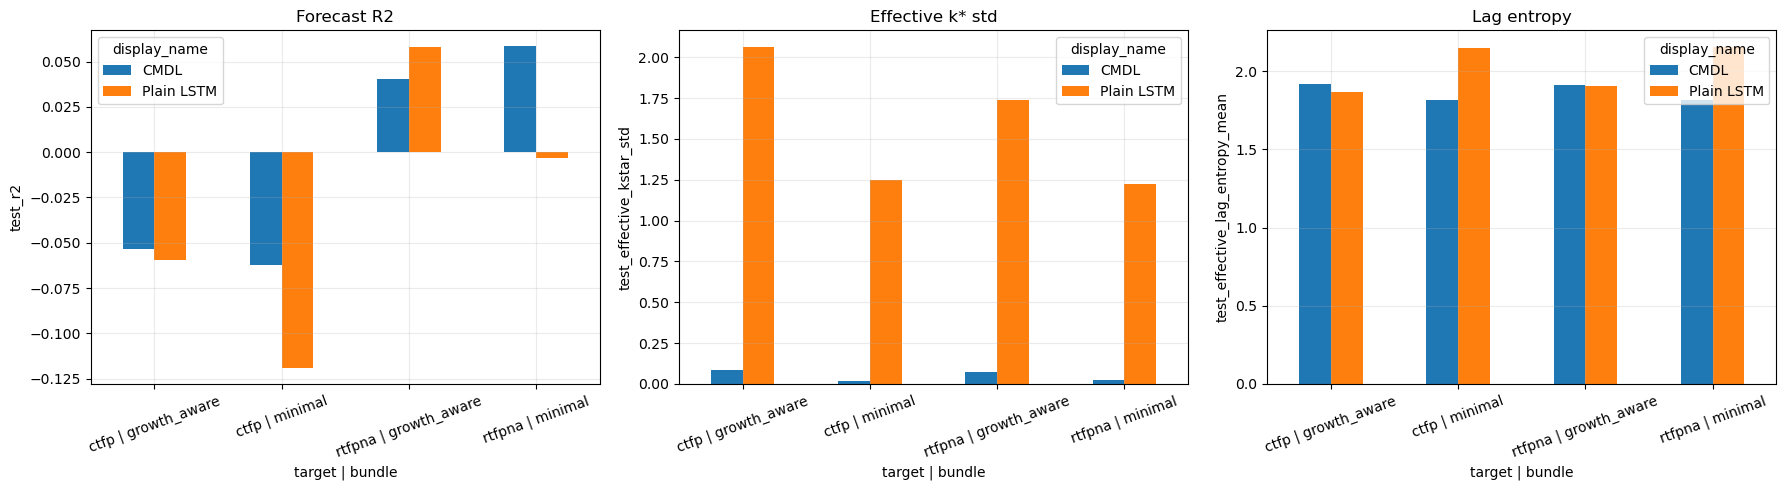

,target_column,feature_bundle,display_name,test_r2,test_effective_kstar_std,test_effective_lag_entropy_mean,test_effective_kstar_proxy_spearman_rho,test_proxy_signal_r2,proxy_refit_status
0,ctfp,growth_aware,CMDL,-0.053619,0.083969,1.916423,0.898797,0.458875,applied_ols
2,ctfp,minimal,CMDL,-0.062092,0.018225,1.817613,-0.473761,0.339445,applied_ols
4,rtfpna,growth_aware,CMDL,0.040156,0.075644,1.914742,0.910118,0.436625,applied_ols
6,rtfpna,minimal,CMDL,0.058391,0.022191,1.815753,-0.491167,0.395200,applied_ols


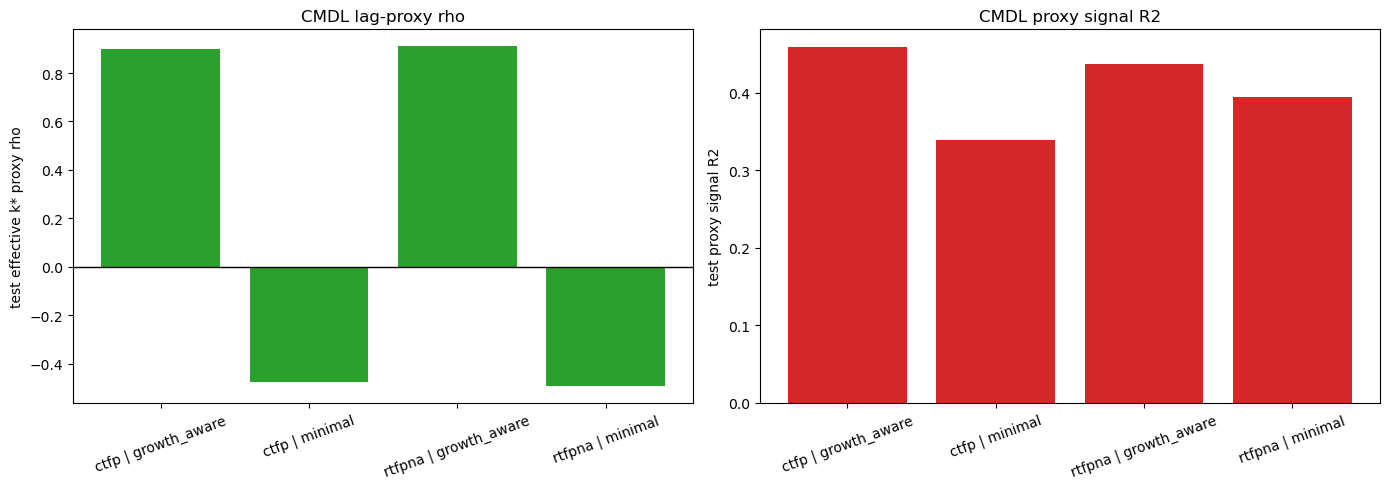

Saved Phase B plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_screening_metrics.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_mechanism_diagnostics.png


In [19]:
if phase_b_comparison.empty:
    print("No Phase B screening results found; skipping plots.")
else:
    phase_b_plot_frame = phase_b_comparison.copy()
    phase_b_plot_frame["setting_label"] = (
        phase_b_plot_frame["target_column"] + " | " + phase_b_plot_frame["feature_bundle"]
    )

    metrics_to_plot = [
        ("test_r2", "Forecast R2"),
        ("test_effective_kstar_std", "Effective k* std"),
        ("test_effective_lag_entropy_mean", "Lag entropy"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for axis, (metric_name, title) in zip(axes, metrics_to_plot):
        pivot = phase_b_plot_frame.pivot(
            index="setting_label",
            columns="display_name",
            values=metric_name,
        ).sort_index()
        pivot.plot(kind="bar", ax=axis)
        axis.set_title(title)
        axis.set_xlabel("target | bundle")
        axis.set_ylabel(metric_name)
        axis.tick_params(axis="x", rotation=20)
        axis.grid(alpha=0.25)
    fig.tight_layout()
    phase_b_metrics_plot_path = PHASE_B_PLOTS_DIR / "phase_b_screening_metrics.png"
    fig.savefig(phase_b_metrics_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    phase_b_cmdl_only = phase_b_plot_frame.loc[phase_b_plot_frame["family"] == "cmdl"].copy()
    display(
        phase_b_cmdl_only[
            [
                "target_column",
                "feature_bundle",
                "display_name",
                "test_r2",
                "test_effective_kstar_std",
                "test_effective_lag_entropy_mean",
                "test_effective_kstar_proxy_spearman_rho",
                "test_proxy_signal_r2",
                "proxy_refit_status",
            ]
        ].sort_values(["target_column", "feature_bundle"])
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(
        phase_b_cmdl_only["setting_label"],
        phase_b_cmdl_only["test_effective_kstar_proxy_spearman_rho"].fillna(0.0),
        color="#2ca02c",
    )
    axes[0].axhline(0.0, color="black", linewidth=1.0)
    axes[0].set_title("CMDL lag-proxy rho")
    axes[0].set_ylabel("test effective k* proxy rho")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(
        phase_b_cmdl_only["setting_label"],
        phase_b_cmdl_only["test_proxy_signal_r2"].fillna(0.0),
        color="#d62728",
    )
    axes[1].set_title("CMDL proxy signal R2")
    axes[1].set_ylabel("test proxy signal R2")
    axes[1].tick_params(axis="x", rotation=20)

    fig.tight_layout()
    phase_b_mechanism_plot_path = PHASE_B_PLOTS_DIR / "phase_b_mechanism_diagnostics.png"
    fig.savefig(phase_b_mechanism_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    print(f"Saved Phase B plots to {phase_b_metrics_plot_path} and {phase_b_mechanism_plot_path}")

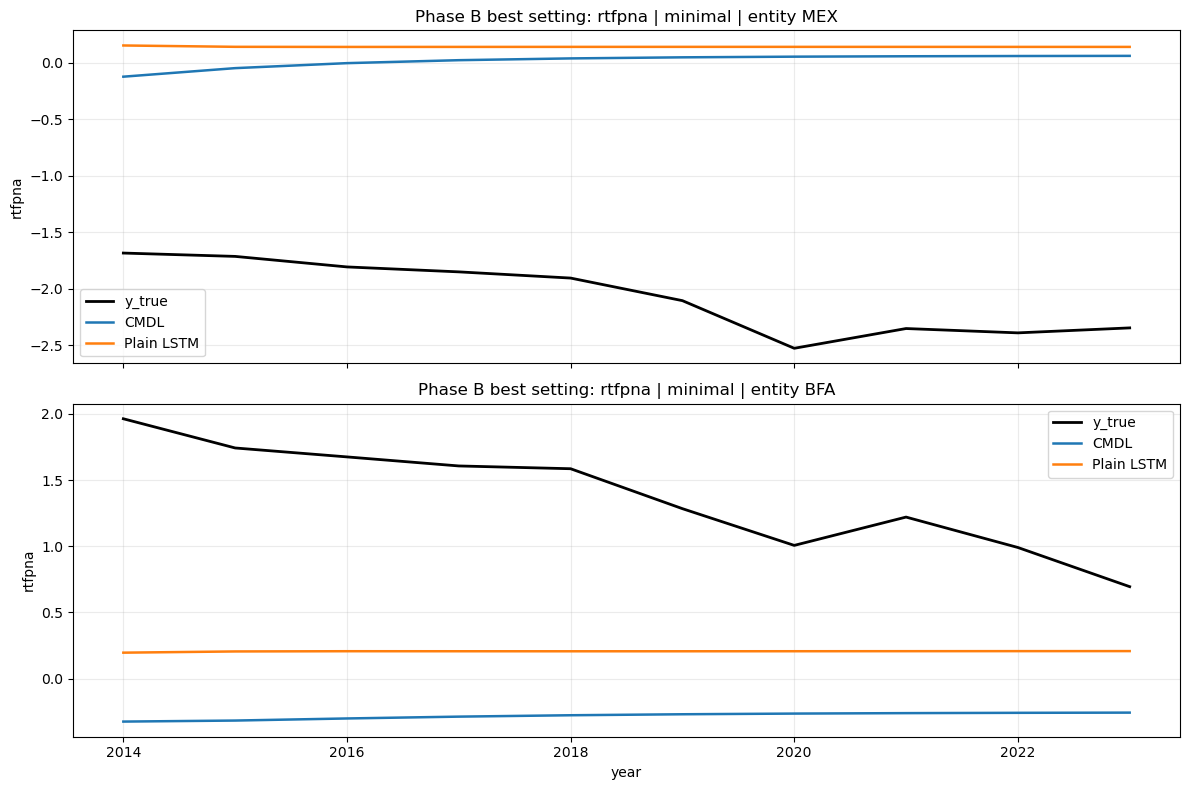

Saved Phase B prediction snapshots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_prediction_snapshots.png


In [20]:
if phase_b_comparison.empty:
    print("No Phase B screening results found; skipping prediction snapshots.")
else:
    phase_b_best_cmdl = phase_b_comparison.loc[phase_b_comparison["family"] == "cmdl"].sort_values(
        ["test_r2", "test_effective_kstar_std"],
        ascending=[False, False],
        na_position="last",
    ).iloc[0]
    phase_b_best_baseline = phase_b_comparison.loc[
        (phase_b_comparison["family"] == "plain_lstm")
        & (phase_b_comparison["target_column"] == phase_b_best_cmdl["target_column"])
        & (phase_b_comparison["feature_bundle"] == phase_b_best_cmdl["feature_bundle"])
    ].iloc[0]

    phase_b_prediction_specs = {
        "CMDL": Path(phase_b_best_cmdl["run_dir"]) / "predictions.csv",
        "Plain LSTM": Path(phase_b_best_baseline["run_dir"]) / "predictions.csv",
    }
    phase_b_prediction_frames: dict[str, pd.DataFrame] = {}
    for label, path in phase_b_prediction_specs.items():
        if path.exists():
            phase_b_prediction_frames[label] = pd.read_csv(path)

    if not phase_b_prediction_frames:
        print("Prediction files are missing; skipping Phase B prediction snapshots.")
    else:
        reference_frame = phase_b_prediction_frames["CMDL"]
        if "k_star" in reference_frame.columns:
            kstar_by_entity = reference_frame.groupby("entity_code", as_index=False)["k_star"].first().sort_values("k_star")
            candidate_codes = kstar_by_entity["entity_code"].tolist()
            entity_codes = candidate_codes[:1] + candidate_codes[-1:]
            entity_codes = list(dict.fromkeys(entity_codes))
        else:
            entity_codes = sorted(reference_frame["entity_code"].unique().tolist())[:2]

        fig, axes = plt.subplots(len(entity_codes), 1, figsize=(12, 4 * len(entity_codes)), sharex=True)
        if len(entity_codes) == 1:
            axes = [axes]

        for axis, entity_code in zip(axes, entity_codes):
            truth_frame = reference_frame[reference_frame["entity_code"] == entity_code]
            axis.plot(truth_frame["year"], truth_frame["y_true"], color="black", linewidth=2.0, label="y_true")
            for label, frame in phase_b_prediction_frames.items():
                entity_frame = frame[frame["entity_code"] == entity_code]
                axis.plot(entity_frame["year"], entity_frame["y_pred"], linewidth=1.8, label=label)
            axis.set_title(
                f"Phase B best setting: {phase_b_best_cmdl['target_column']} | {phase_b_best_cmdl['feature_bundle']} | entity {entity_code}"
            )
            axis.set_ylabel(phase_b_best_cmdl["target_column"])
            axis.grid(alpha=0.25)
            axis.legend()

        axes[-1].set_xlabel("year")
        fig.tight_layout()
        phase_b_prediction_plot_path = PHASE_B_PLOTS_DIR / "phase_b_prediction_snapshots.png"
        fig.savefig(phase_b_prediction_plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved Phase B prediction snapshots to {phase_b_prediction_plot_path}")

## Formal Mechanism Suite / 正式机制验证

This section upgrades the strongest economics mechanism claim from Phase B screening to a formal suite: `ctfp` + `growth_aware`, three seeds, and same-bundle ablations.
本节把 Phase B 的最强机制候选升级为正式验证：`ctfp` + `growth_aware`，3 个随机种子，并加入同 bundle 的 ablation 来检验必要性。

In [21]:
import importlib

from experiments import run_economics_ablation as run_economics_ablation_module

run_economics_ablation_module = importlib.reload(run_economics_ablation_module)
run_ablation_suite = run_economics_ablation_module.run_suite

FORMAL_MECHANISM_TARGET = "ctfp"
FORMAL_MECHANISM_FEATURE_BUNDLE = "growth_aware"
FORMAL_MECHANISM_SEEDS = [0, 1, 2]
FORMAL_MECHANISM_PRESET = dict(PRESET_CONFIGS["formal_target"])
FORMAL_MECHANISM_DEVICE = "cpu"
FORMAL_MECHANISM_DISABLE_MLFLOW = True
FORMAL_MECHANISM_DATA_PATH = PHASE_B_DATA_PATH
FORMAL_MECHANISM_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / "formal_mechanism_ctfp_growth_aware"
FORMAL_MECHANISM_CMDL_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "cmdl"
FORMAL_MECHANISM_BASELINE_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "plain_lstm"
FORMAL_MECHANISM_ABLATION_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "ablation"
FORMAL_MECHANISM_COMPARISON_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "comparison"
FORMAL_MECHANISM_PLOTS_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "comparison_plots"

for path in [
    FORMAL_MECHANISM_OUTPUT_ROOT,
    FORMAL_MECHANISM_CMDL_DIR,
    FORMAL_MECHANISM_BASELINE_DIR,
    FORMAL_MECHANISM_ABLATION_DIR,
    FORMAL_MECHANISM_COMPARISON_DIR,
    FORMAL_MECHANISM_PLOTS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

formal_mechanism_settings = pd.DataFrame(
    {
        "value": [
            FORMAL_MECHANISM_DATA_PATH,
            FORMAL_MECHANISM_TARGET,
            FORMAL_MECHANISM_FEATURE_BUNDLE,
            ", ".join(str(seed) for seed in FORMAL_MECHANISM_SEEDS),
            FORMAL_MECHANISM_PRESET["epochs"],
            FORMAL_MECHANISM_PRESET["patience"],
            FORMAL_MECHANISM_DEVICE,
            FORMAL_MECHANISM_DISABLE_MLFLOW,
            FORMAL_MECHANISM_OUTPUT_ROOT,
        ]
    },
    index=[
        "FORMAL_MECHANISM_DATA_PATH",
        "FORMAL_MECHANISM_TARGET",
        "FORMAL_MECHANISM_FEATURE_BUNDLE",
        "FORMAL_MECHANISM_SEEDS",
        "FORMAL_MECHANISM_EPOCHS",
        "FORMAL_MECHANISM_PATIENCE",
        "FORMAL_MECHANISM_DEVICE",
        "FORMAL_MECHANISM_DISABLE_MLFLOW",
        "FORMAL_MECHANISM_OUTPUT_ROOT",
    ],
)

display(formal_mechanism_settings)

,value
FORMAL_MECHANISM_DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
FORMAL_MECHANISM_TARGET,ctfp
FORMAL_MECHANISM_FEATURE_BUNDLE,growth_aware
FORMAL_MECHANISM_SEEDS,"0, 1, 2"
FORMAL_MECHANISM_EPOCHS,120
FORMAL_MECHANISM_PATIENCE,20
FORMAL_MECHANISM_DEVICE,cpu
FORMAL_MECHANISM_DISABLE_MLFLOW,True
FORMAL_MECHANISM_OUTPUT_ROOT,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...


In [23]:
formal_cmdl_summaries: list[dict[str, object]] = []
formal_baseline_summaries: list[dict[str, object]] = []

for seed in FORMAL_MECHANISM_SEEDS:
    shared_args = {
        **COMMON_ARGS,
        **FORMAL_MECHANISM_PRESET,
        "csv_path": str(FORMAL_MECHANISM_DATA_PATH),
        "target_column": FORMAL_MECHANISM_TARGET,
        "feature_bundle": FORMAL_MECHANISM_FEATURE_BUNDLE,
        "seed": seed,
        "device": FORMAL_MECHANISM_DEVICE,
        "disable_mlflow": FORMAL_MECHANISM_DISABLE_MLFLOW,
        "smoke": False,
    }

    cmdl_args = Namespace(
        **shared_args,
        output_dir=str(FORMAL_MECHANISM_CMDL_DIR),
        experiment_name=f"formal_mechanism_cmdl_seed{seed}",
    )
    cmdl_summary = run_cmdl_experiment(cmdl_args)
    formal_cmdl_summaries.append(cmdl_summary)
    print(
        f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
        f"rho={cmdl_summary['metrics']['test']['kstar_proxy_spearman_rho']:.4f} "
        f"kstar_std={cmdl_summary['metrics']['test']['kstar_std']:.4f}"
    )

    baseline_args = Namespace(
        **shared_args,
        output_dir=str(FORMAL_MECHANISM_BASELINE_DIR),
        experiment_name=f"formal_mechanism_lstm_seed{seed}",
    )
    baseline_summary = run_baseline_experiment(baseline_args)
    formal_baseline_summaries.append(baseline_summary)
    print(
        f"Baseline seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
        f"rho={baseline_summary['metrics']['test']['posthoc_kstar_proxy_spearman_rho']:.4f} "
        f"kstar_std={baseline_summary['metrics']['test']['posthoc_kstar_std']:.4f}"
    )

formal_ablation_shared_args = {
    **COMMON_ARGS,
    **FORMAL_MECHANISM_PRESET,
    "csv_path": str(FORMAL_MECHANISM_DATA_PATH),
    "target_column": FORMAL_MECHANISM_TARGET,
    "feature_bundle": FORMAL_MECHANISM_FEATURE_BUNDLE,
    "seeds": FORMAL_MECHANISM_SEEDS,
    "variant": "all",
    "output_dir": str(FORMAL_MECHANISM_ABLATION_DIR),
    "experiment_prefix": "formal_mechanism_ablation",
    "device": FORMAL_MECHANISM_DEVICE,
    "disable_mlflow": FORMAL_MECHANISM_DISABLE_MLFLOW,
    "smoke": False,
}
formal_ablation_args = Namespace(**formal_ablation_shared_args)
formal_ablation_summary_frame, formal_ablation_aggregated_frame = run_ablation_suite(formal_ablation_args)
if not formal_ablation_aggregated_frame.empty:
    display(formal_ablation_aggregated_frame)

[formal_mechanism_cmdl_seed0] epoch=001 train_total=1.5494 val_task=3.1232 val_r2=-0.1156 val_proxy_r2=-0.2467
[formal_mechanism_cmdl_seed0] epoch=010 train_total=0.7311 val_task=2.7093 val_r2=0.0424 val_proxy_r2=-0.2333
[formal_mechanism_cmdl_seed0] epoch=020 train_total=0.5753 val_task=2.7632 val_r2=-0.0211 val_proxy_r2=-0.2633
[formal_mechanism_cmdl_seed0] epoch=030 train_total=0.4485 val_task=2.7141 val_r2=0.0077 val_proxy_r2=-0.3051
[formal_mechanism_cmdl_seed0] epoch=040 train_total=0.3634 val_task=2.9889 val_r2=-0.1092 val_proxy_r2=-0.3470
[formal_mechanism_cmdl_seed0] early stopping at epoch 45
CMDL seed=0 test_r2=0.0423 rho=-0.5462 kstar_std=0.0833
[formal_mechanism_lstm_seed0] epoch=001 train_task=1.1841 val_task=3.0659 val_mae=1.3185 val_r2=-0.1020
[formal_mechanism_lstm_seed0] epoch=010 train_task=0.5842 val_task=2.9022 val_mae=1.3056 val_r2=-0.0322
[formal_mechanism_lstm_seed0] epoch=020 train_task=0.4457 val_task=2.8007 val_mae=1.3152 val_r2=-0.0269
[formal_mechanism_lstm

,variant,target_column,effective_lambda_r_mean,effective_lambda_r_std,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,best_val_task_loss_std,proxy_refit_applied_mean,proxy_refit_applied_std,...,test_kstar_proxy_spearman_p_mean,test_kstar_proxy_spearman_p_std,test_kstar_mean_mean,test_kstar_mean_std,test_kstar_std_mean,test_kstar_std_std,test_kstar_proxy_metric_valid_mean,test_kstar_proxy_metric_valid_std,test_omega_entropy_mean_mean,test_omega_entropy_mean_std
0,no_ac_encoder,ctfp,0.0,0.0,13.666667,6.027714,2.708152,0.106468,0.0,0.0,...,1.000000e+00,0.000000e+00,4.693914,0.919561,3.962269e-07,4.943958e-07,0.666667,0.57735,1.786672,0.135642
1,no_recon_regularization,ctfp,0.0,0.0,19.666667,6.110101,2.694780,0.095036,1.0,0.0,...,1.777603e-29,3.075056e-29,4.471726,0.425002,2.221954e-01,1.633344e-01,1.000000,0.00000,1.801118,0.146291
2,uniform_lag,ctfp,0.1,0.0,22.333333,8.326664,2.664400,0.062731,1.0,0.0,...,NaN,NaN,5.500000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.00000,2.302585,0.000000


In [24]:
formal_mechanism_comparison = build_economics_comparison(
    cmdl_root=FORMAL_MECHANISM_CMDL_DIR,
    baseline_root=FORMAL_MECHANISM_BASELINE_DIR,
    ablation_root=FORMAL_MECHANISM_ABLATION_DIR,
)
formal_mechanism_task_table = build_task_table(formal_mechanism_comparison)
formal_mechanism_interpretability_table = build_interpretability_table(formal_mechanism_comparison)

formal_mechanism_comparison.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_comparison.csv", index=False)
formal_mechanism_task_table.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_forecast_comparison.csv", index=False)
formal_mechanism_interpretability_table.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_interpretability_comparison.csv", index=False)

def aggregate_mechanism_summary(frame: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "test_r2",
        "test_effective_kstar_proxy_spearman_rho",
        "test_effective_kstar_std",
        "test_effective_lag_entropy_mean",
        "test_proxy_signal_r2",
    ]
    aggregated = frame.groupby(["display_name", "family", "variant"], dropna=False)[metrics].agg(["mean", "std"])
    aggregated.columns = [
        column if isinstance(column, str) else "_".join(part for part in column if part)
        for column in aggregated.columns.to_flat_index()
    ]
    aggregated = aggregated.reset_index()
    sign_rows: list[dict[str, object]] = []
    for (display_name, family, variant), group in frame.groupby(["display_name", "family", "variant"], dropna=False):
        rho_series = group["test_effective_kstar_proxy_spearman_rho"].dropna()
        sign_rows.append(
            {
                "display_name": display_name,
                "family": family,
                "variant": variant,
                "rho_positive_seed_share": float((rho_series > 0.0).mean()) if not rho_series.empty else np.nan,
                "rho_all_positive": bool((rho_series > 0.0).all()) if not rho_series.empty else False,
                "seed_count": int(group["seed"].nunique()),
            }
        )
    sign_frame = pd.DataFrame(sign_rows)
    return aggregated.merge(sign_frame, on=["display_name", "family", "variant"], how="left")

formal_mechanism_summary = aggregate_mechanism_summary(formal_mechanism_comparison)
formal_mechanism_summary.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_seed_summary.csv", index=False)

display(formal_mechanism_task_table)
display(formal_mechanism_interpretability_table)
display(formal_mechanism_summary.sort_values(["family", "display_name"], na_position="last"))

,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,Uniform Lag,ablation,uniform_lag,0,formal_mechanism_ablation_uniform_lag_seed0,ctfp,growth_aware,25,2.596867,0.063570,1.511100,3.880958
1,Plain LSTM,plain_lstm,None,1,formal_mechanism_lstm_seed1,ctfp,growth_aware,25,2.640993,0.060620,1.523484,3.893575
2,Plain LSTM,plain_lstm,None,2,formal_mechanism_lstm_seed2,ctfp,growth_aware,12,2.605581,0.059953,1.497608,3.900793
3,Plain LSTM,plain_lstm,None,0,formal_mechanism_lstm_seed0,ctfp,growth_aware,23,2.692956,0.050822,1.519800,3.934121
4,CMDL,cmdl,None,0,formal_mechanism_cmdl_seed0,ctfp,growth_aware,25,2.632056,0.042290,1.515038,3.972353
5,Uniform Lag,ablation,uniform_lag,2,formal_mechanism_ablation_uniform_lag_seed2,ctfp,growth_aware,29,2.720852,0.031237,1.533743,4.014152
6,No Recon Regularization,ablation,no_recon_regularization,0,formal_mechanism_ablation_no_recon_regularizat...,ctfp,growth_aware,21,2.650039,0.026887,1.531019,4.038982
7,CMDL,cmdl,None,1,formal_mechanism_cmdl_seed1,ctfp,growth_aware,23,2.642155,0.025391,1.548320,4.042825
8,Uniform Lag,ablation,uniform_lag,1,formal_mechanism_ablation_uniform_lag_seed1,ctfp,growth_aware,13,2.675482,0.022649,1.519917,4.052731
9,No AC Encoder,ablation,no_ac_encoder,0,formal_mechanism_ablation_no_ac_encoder_seed0,ctfp,growth_aware,20,2.661245,0.022620,1.532274,4.057062


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,proxy_refit_status,proxy_metric_interpretable,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_metric_valid,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2,test_proxy_signal_metric_valid
0,Plain LSTM,plain_lstm,None,2,formal_mechanism_lstm_seed2,ctfp,growth_aware,lag_occlusion,None,None,0.308819,None,5.515690,1.811419e+00,1.935223,NaN,None
1,CMDL,cmdl,None,1,formal_mechanism_cmdl_seed1,ctfp,growth_aware,learned_omega,applied_ols,True,0.292318,True,4.791158,7.931699e-03,2.021600,0.465184,True
2,Plain LSTM,plain_lstm,None,1,formal_mechanism_lstm_seed1,ctfp,growth_aware,lag_occlusion,None,None,0.044195,None,5.521010,1.978468e+00,1.860436,NaN,None
3,Plain LSTM,plain_lstm,None,0,formal_mechanism_lstm_seed0,ctfp,growth_aware,lag_occlusion,None,None,0.012976,None,5.414590,1.954355e+00,1.820190,NaN,None
4,No AC Encoder,ablation,no_ac_encoder,1,formal_mechanism_ablation_no_ac_encoder_seed1,ctfp,growth_aware,learned_omega,skipped_rank_deficient,False,0.000000,True,3.987115,2.384186e-07,1.669010,NaN,False
5,No AC Encoder,ablation,no_ac_encoder,2,formal_mechanism_ablation_no_ac_encoder_seed2,ctfp,growth_aware,learned_omega,skipped_rank_deficient,False,0.000000,True,5.733549,9.502622e-07,1.755974,NaN,False
6,CMDL,cmdl,None,0,formal_mechanism_cmdl_seed0,ctfp,growth_aware,learned_omega,applied_ols,True,-0.546237,True,4.061123,8.326524e-02,1.876468,0.279514,True
7,No Recon Regularization,ablation,no_recon_regularization,2,formal_mechanism_ablation_no_recon_regularizat...,ctfp,growth_aware,learned_omega,applied_ols,True,-0.839156,True,4.828722,3.814881e-01,1.766174,0.411775,True
8,No Recon Regularization,ablation,no_recon_regularization,1,formal_mechanism_ablation_no_recon_regularizat...,ctfp,growth_aware,learned_omega,applied_ols,True,-0.861456,True,4.001609,5.509900e-02,1.675464,0.411864,True
9,CMDL,cmdl,None,2,formal_mechanism_cmdl_seed2,ctfp,growth_aware,learned_omega,applied_ols,True,-0.874953,True,3.741207,6.577467e-03,1.797221,0.414589,True


,display_name,family,variant,test_r2_mean,test_r2_std,test_effective_kstar_proxy_spearman_rho_mean,test_effective_kstar_proxy_spearman_rho_std,test_effective_kstar_std_mean,test_effective_kstar_std_std,test_effective_lag_entropy_mean_mean,test_effective_lag_entropy_mean_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std,rho_positive_seed_share,rho_all_positive,seed_count
1,No AC Encoder,ablation,no_ac_encoder,0.000026,0.032954,0.000000,0.000000,3.962269e-07,4.943958e-07,1.786672,0.135642,NaN,NaN,0.000000,False,3
2,No Recon Regularization,ablation,no_recon_regularization,0.005126,0.028304,-0.889820,0.069342,2.221954e-01,1.633344e-01,1.801118,0.146291,0.430585,0.032502,0.000000,False,3
4,Uniform Lag,ablation,uniform_lag,0.039152,0.021578,NaN,NaN,0.000000e+00,0.000000e+00,2.302585,0.000000,0.425717,0.012095,NaN,False,3
0,CMDL,cmdl,NaN,0.020776,0.024155,-0.376291,0.601907,3.259147e-02,4.389000e-02,1.898430,0.113790,0.386429,0.095984,0.333333,False,3
3,Plain LSTM,plain_lstm,NaN,0.057132,0.005475,0.121997,0.162544,1.914747e+00,9.029359e-02,1.871950,0.058374,NaN,NaN,1.000000,True,3


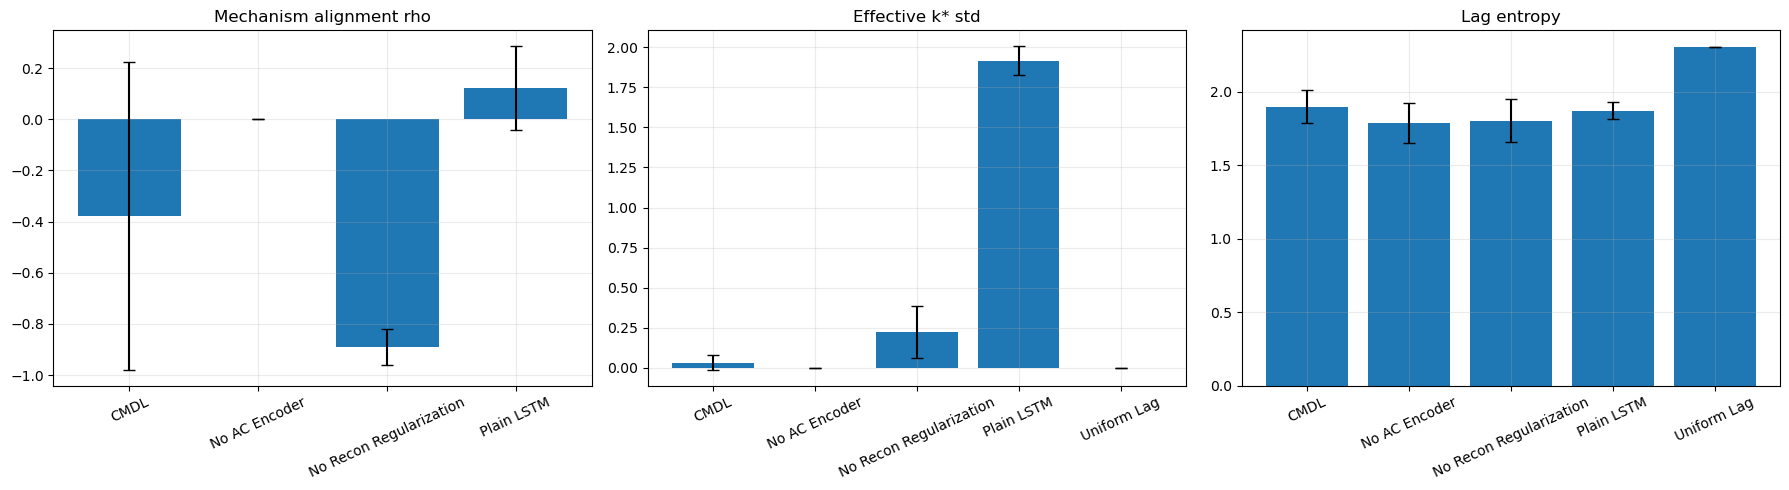

display_name,CMDL,No AC Encoder,No Recon Regularization,Plain LSTM,Uniform Lag
seed,,,,,
0,-0.546237,NaN,-0.968847,0.012976,NaN
1,0.292318,0.0,-0.861456,0.044195,NaN
2,-0.874953,0.0,-0.839156,0.308819,NaN


,display_name,rho_all_positive,rho_positive_seed_share,mean_rho,mean_kstar_std,mean_entropy,mean_test_r2
3,Plain LSTM,True,1.000000,0.121997,1.914747e+00,1.871950,0.057132
1,No AC Encoder,False,0.000000,0.000000,3.962269e-07,1.786672,0.000026
0,CMDL,False,0.333333,-0.376291,3.259147e-02,1.898430,0.020776
2,No Recon Regularization,False,0.000000,-0.889820,2.221954e-01,1.801118,0.005126
4,Uniform Lag,False,NaN,NaN,0.000000e+00,2.302585,0.039152


ValueError: invalid literal for int() with base 10: 'peak'

In [ ]:
if formal_mechanism_summary.empty:
    print("No formal mechanism results found; skipping plots.")
else:
    plot_frame = formal_mechanism_summary.copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_specs = [
        ("test_effective_kstar_proxy_spearman_rho_mean", "test_effective_kstar_proxy_spearman_rho_std", "Mechanism alignment rho"),
        ("test_effective_kstar_std_mean", "test_effective_kstar_std_std", "Effective k* std"),
        ("test_effective_lag_entropy_mean_mean", "test_effective_lag_entropy_mean_std", "Lag entropy"),
    ]
    for axis, (mean_col, std_col, title) in zip(axes, metric_specs):
        axis.bar(plot_frame["display_name"], plot_frame[mean_col], yerr=plot_frame[std_col].fillna(0.0), capsize=4)
        axis.set_title(title)
        axis.tick_params(axis="x", rotation=25)
        axis.grid(alpha=0.25)
    fig.tight_layout()
    formal_mechanism_plot_path = FORMAL_MECHANISM_PLOTS_DIR / "formal_mechanism_summary.png"
    fig.savefig(formal_mechanism_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    sign_frame = formal_mechanism_comparison[["display_name", "seed", "test_effective_kstar_proxy_spearman_rho"]].copy()
    sign_pivot = sign_frame.pivot(index="seed", columns="display_name", values="test_effective_kstar_proxy_spearman_rho")
    display(sign_pivot)

    criteria_rows = []
    for _, row in formal_mechanism_summary.iterrows():
        criteria_rows.append(
            {
                "display_name": row["display_name"],
                "rho_all_positive": row["rho_all_positive"],
                "rho_positive_seed_share": row["rho_positive_seed_share"],
                "mean_rho": row["test_effective_kstar_proxy_spearman_rho_mean"],
                "mean_kstar_std": row["test_effective_kstar_std_mean"],
                "mean_entropy": row["test_effective_lag_entropy_mean_mean"],
                "mean_test_r2": row["test_r2_mean"],
            }
        )
    formal_mechanism_criteria = pd.DataFrame(criteria_rows).sort_values("mean_rho", ascending=False, na_position="last")
    formal_mechanism_criteria.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_criteria.csv", index=False)
    display(formal_mechanism_criteria)

    omega_frames = []
    for seed in FORMAL_MECHANISM_SEEDS:
        prediction_path = FORMAL_MECHANISM_CMDL_DIR / f"formal_mechanism_cmdl_seed{seed}" / "predictions.csv"
        if not prediction_path.exists():
            continue
        frame = pd.read_csv(prediction_path)
        omega_columns = sorted(
            [
                column
                for column in frame.columns
                if column.startswith("omega_") and column.split("_")[1].isdigit()
            ],
            key=lambda name: int(name.split("_")[1]),
        )
        entity_frame = frame.groupby("entity_code", as_index=False)[omega_columns].first()
        proxy_by_entity = frame.groupby("entity_code", as_index=False)["proxy_1_true"].first()
        entity_frame = entity_frame.merge(proxy_by_entity, on="entity_code", how="left")
        entity_frame = entity_frame.sort_values("proxy_1_true").reset_index(drop=True)
        omega_frames.append((seed, entity_frame[omega_columns].to_numpy(dtype=float)))

    if omega_frames:
        fig, axes = plt.subplots(len(omega_frames), 1, figsize=(10, 3.5 * len(omega_frames)), sharex=True)
        if len(omega_frames) == 1:
            axes = [axes]
        for axis, (seed, omega_matrix) in zip(axes, omega_frames):
            image = axis.imshow(omega_matrix, aspect="auto", cmap="viridis")
            axis.set_title(f"CMDL omega heatmap by proxy rank (seed={seed})")
            axis.set_ylabel("entities sorted by proxy")
            fig.colorbar(image, ax=axis, fraction=0.020, pad=0.02)
        axes[-1].set_xlabel("lag index")
        fig.tight_layout()
        formal_mechanism_heatmap_path = FORMAL_MECHANISM_PLOTS_DIR / "formal_mechanism_omega_heatmaps.png"
        fig.savefig(formal_mechanism_heatmap_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved formal mechanism plots to {formal_mechanism_plot_path} and {formal_mechanism_heatmap_path}")
    else:
        print(f"Saved formal mechanism plot to {formal_mechanism_plot_path}")